## Cài đặt


In [ ]:
!pip install ultralytics roboflow

import os
from roboflow import Roboflow
api_key = os.getenv("ROBOFLOW_API_KEY", "YOUR_ROBOFLOW_API_KEY")
rf = Roboflow(api_key=api_key)
project = rf.workspace("thanh-tung-phan").project("biensoxe-o1lhe")
version = project.version(1)
dataset = version.download("yolov8")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BienSoXe-1 in yolov8:: 100%|██████████| 2529/2529 [00:00<00:00, 3803.01it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## Chạy huấn luyện

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    project="alpr_vn",
    name="yolov8n_bienso"
)

Ultralytics 8.4.168 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BienSoXe-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_bienso, nbs=64, nms=None, opset=None, optimize=Fals

## Kiểm tra biểu đồ huấn luyện

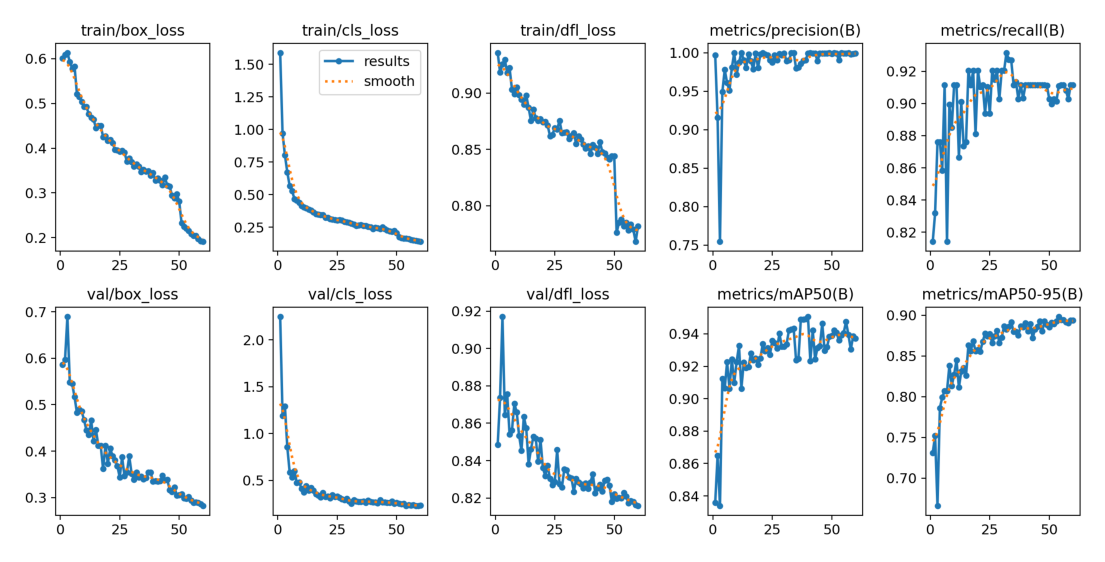

In [3]:
import matplotlib.pyplot as plt
import cv2

chart_path = "/content/runs/detect/alpr_vn/yolov8n_bienso/results.png"
img = cv2.imread(chart_path)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Chạy huấn luyện phát hiện trên tập Test


image 1/53 /content/BienSoXe-1/test/images/BienSoXe-101-_jpg.rf.ae3c6c37092d2d2ab16ad9ba3686f7b6.jpg: 640x640 1 BienSoXe, 17.2ms
image 2/53 /content/BienSoXe-1/test/images/BienSoXe-117-_jpg.rf.e152c179ebfc2cf05fa16c818ba1c846.jpg: 640x640 1 BienSoXe, 13.6ms
image 3/53 /content/BienSoXe-1/test/images/BienSoXe-129-_jpg.rf.d76be6f76466fc42a55a79016d898390.jpg: 640x640 1 BienSoXe, 16.3ms
image 4/53 /content/BienSoXe-1/test/images/BienSoXe-169-_jpg.rf.0305ea108eb659504ca08f6addf1cc11.jpg: 640x640 1 BienSoXe, 15.3ms
image 5/53 /content/BienSoXe-1/test/images/BienSoXe-171-_jpg.rf.78df54af27a190b300fdbf333931f3bf.jpg: 640x640 1 BienSoXe, 12.8ms
image 6/53 /content/BienSoXe-1/test/images/BienSoXe-172-_jpg.rf.f99c1809f541cdb91c9075ebd663bc1a.jpg: 640x640 1 BienSoXe, 15.7ms
image 7/53 /content/BienSoXe-1/test/images/BienSoXe-173-_jpg.rf.9fd31404cf02eabdf78d4e43b4d6a72a.jpg: 640x640 1 BienSoXe, 15.5ms
image 8/53 /content/BienSoXe-1/test/images/BienSoXe-175-_jpg.rf.7cc3f85b662d272e819e50a196961368

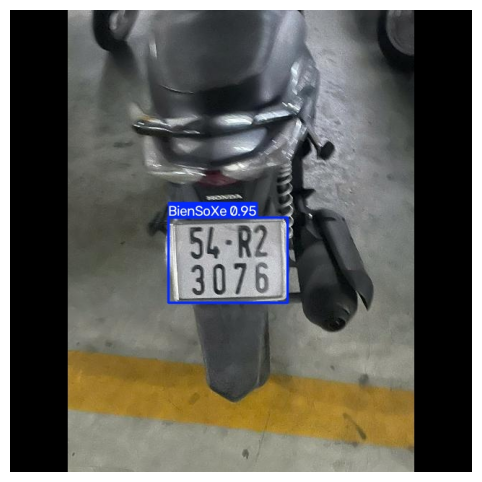

In [4]:
model = YOLO("/content/runs/detect/alpr_vn/yolov8n_bienso/weights/best.pt")
test_results = model.predict(source=f"{dataset.location}/test/images", conf=0.5, save=True)

import glob
predicted_images = glob.glob("runs/detect/predict/*.jpg")
if predicted_images:
    sample_res = cv2.imread(predicted_images[0])
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(sample_res, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [5]:
from google.colab import files

files.download("/content/runs/detect/alpr_vn/yolov8n_bienso/weights/best.pt")
files.download("/content/runs/detect/alpr_vn/yolov8n_bienso/results.png")
files.download("/content/runs/detect/alpr_vn/yolov8n_bienso/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>